In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx",header=0)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [9]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [10]:
y = df["Churn Label"]

In [11]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [12]:
X = df.drop(columns=[
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
])

In [13]:
print(X.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [14]:
X = X.drop(columns=[
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
])

In [15]:
print(X.columns.tolist())
print(X.shape)


['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']
(7043, 19)


In [16]:
print(y.head())
print(y.value_counts())


0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Churn Label, dtype: str
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 19)
(1409, 19)
Churn Label
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn Label
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [19]:
X_train.select_dtypes(include="object").columns

/var/folders/7x/t1q94c9j0991p54jcs104cm40000gn/T/ipykernel_2807/981028811.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include="object").columns


Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='str')

In [20]:
X_train.select_dtypes(exclude="object").columns

Index(['Tenure Months', 'Monthly Charges'], dtype='str')

In [21]:
print(X_train["Total Charges"].head(10))
print(X_train["Total Charges"].dtype)

4626    1701.65
4192    1151.55
5457     590.35
4717     1905.7
4673      44.55
3840     5196.1
3823       19.8
2010     2379.1
6112     3808.2
3535    4847.05
Name: Total Charges, dtype: object
object


In [22]:
print(X_train["Total Charges"].isnull().sum())

0


In [23]:
X_train["Total Charges"] = pd.to_numeric(
    X_train["Total Charges"],
    errors="coerce"
)

X_test["Total Charges"] = pd.to_numeric(
    X_test["Total Charges"],
    errors="coerce"
)

In [24]:
print(X_train["Total Charges"].isnull().sum())
print(X_test["Total Charges"].isnull().sum())


8
3


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = X_train.select_dtypes(include="object").columns.tolist()


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

/var/folders/7x/t1q94c9j0991p54jcs104cm40000gn/T/ipykernel_2807/2792543656.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


In [26]:
preprocessor = ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [27]:
print(X_train_processed.shape)
print(X_test_processed.shape)


(5634, 46)
(1409, 46)


In [28]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})



In [29]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [30]:
model = Sequential([
    Dense(32,activation="relu",input_shape=(46,)),
    Dense(16,activation="relu"),
    Dense(8,activation="relu"),
    Dense(1,activation="sigmoid")
])

/Users/anmol/Ann_project/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", "recall"]
)

In [32]:
history = model.fit(
    X_train_processed,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7176 - loss: 0.5168 - recall: 0.1717 - val_accuracy: 0.7844 - val_loss: 0.4526 - val_recall: 0.5661
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8036 - loss: 0.4141 - recall: 0.5500 - val_accuracy: 0.7941 - val_loss: 0.4369 - val_recall: 0.5966
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8107 - loss: 0.4000 - recall: 0.5750 - val_accuracy: 0.7924 - val_loss: 0.4241 - val_recall: 0.5186
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8105 - loss: 0.3920 - recall: 0.5650 - val_accuracy: 0.7986 - val_loss: 0.4211 - val_recall: 0.4644
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8176 - loss: 0.3870 - recall: 0.5825 - val_accuracy: 0.7995 - val_loss: 0.4204 - val_recall: 0.5220
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8183 - loss: 0.3864 - recall: 0.5892 - val_accuracy: 0.7924 - val_loss: 0.4206 - val_recall: 0.5593
Epoc

In [33]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'recall', 'val_accuracy', 'val_loss', 'val_recall'])


In [34]:
model.evaluate(X_test_processed,y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7984 - loss: 0.4189 - recall: 0.5080 


[0.41893815994262695, 0.7984386086463928, 0.5080214142799377]

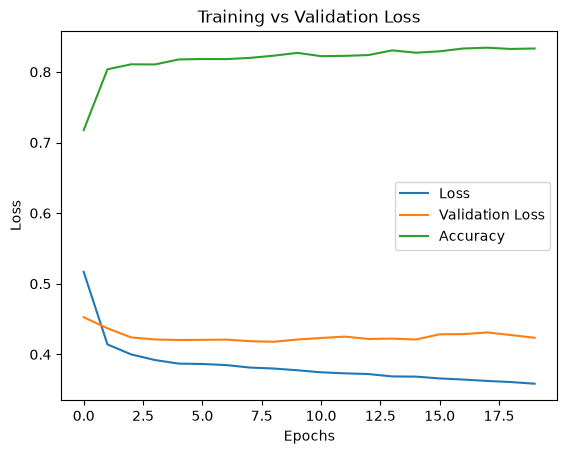

In [35]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.plot(history.history["accuracy"], label="Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

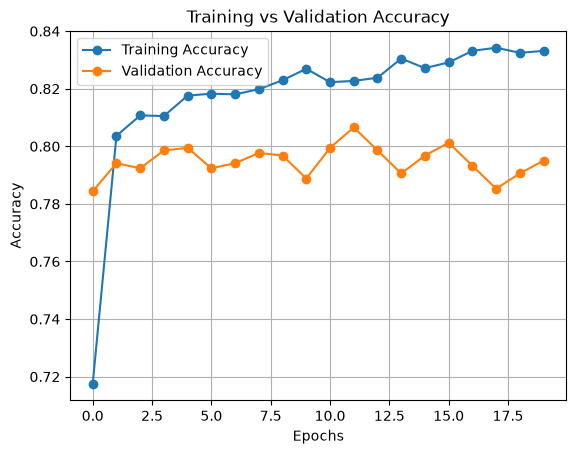

In [36]:
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

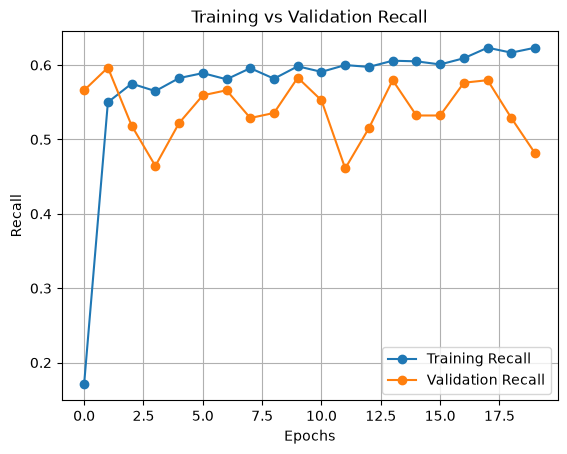

In [37]:
plt.plot(history.history["recall"], marker="o", label="Training Recall")
plt.plot(history.history["val_recall"], marker="o", label="Validation Recall")

plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.grid()
plt.show()

In [38]:
y_pred_prob = model.predict(X_test_processed)
print(y_pred_prob)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[8.6104974e-02]
 [7.9579705e-01]
 [2.2284711e-02]
 ...
 [1.5818597e-01]
 [8.1110140e-03]
 [4.6496061e-04]]


In [42]:
y_pred = (y_pred_prob >= 0.3).astype(int)
print(y_pred)

[[0]
 [1]
 [0]
 ...
 [0]
 [0]
 [0]]


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[807 228]
 [ 94 280]]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1035
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.2 | Precision: 0.50 | Recall: 0.87 | F1: 0.63
Threshold: 0.25 | Precision: 0.52 | Recall: 0.79 | F1: 0.63
Threshold: 0.3 | Precision: 0.55 | Recall: 0.75 | F1: 0.63
Threshold: 0.35 | Precision: 0.57 | Recall: 0.68 | F1: 0.62
Threshold: 0.4 | Precision: 0.59 | Recall: 0.62 | F1: 0.61
Threshold: 0.45 | Precision: 0.62 | Recall: 0.57 | F1: 0.59
Threshold: 0.5 | Precision: 0.66 | Recall: 0.51 | F1: 0.57


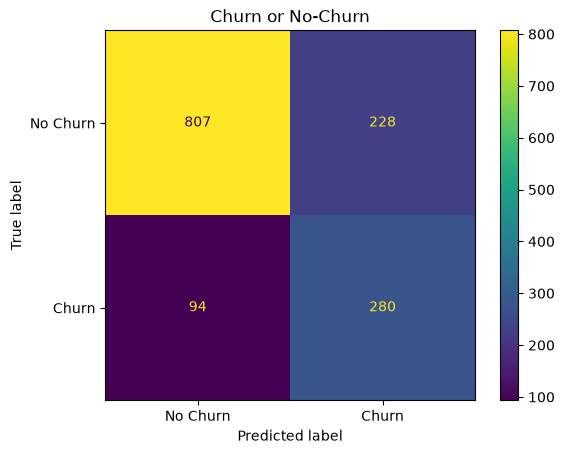

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Churn or No-Churn")
plt.show()

In [51]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [52]:
model.save("ann_model.keras")
print("ANN model saved successfully!")

ANN model saved successfully!


In [53]:
import joblib
from tensorflow.keras.models import load_model

preprocessor_loaded = joblib.load("preprocessor.pkl")
model_loaded = load_model("ann_model.keras")

print("Preprocessor loaded:", type(preprocessor_loaded))
print("Model loaded successfully!")

Preprocessor loaded: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model loaded successfully!
